<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Описание-проекта" data-toc-modified-id="Описание-проекта-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Описание проекта</a></span></li><li><span><a href="#Первичный-анализ-данных" data-toc-modified-id="Первичный-анализ-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Первичный анализ данных</a></span><ul class="toc-item"><li><span><a href="#Датасет-&quot;contract&quot;" data-toc-modified-id="Датасет-&quot;contract&quot;-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Датасет "contract"</a></span><ul class="toc-item"><li><span><a href="#Статистика-по-полю-'monthly_charges'" data-toc-modified-id="Статистика-по-полю-'monthly_charges'-2.1.1"><span class="toc-item-num">2.1.1&nbsp;&nbsp;</span>Статистика по полю 'monthly_charges'</a></span></li><li><span><a href="#Статистика-по-полю-'total_charges'" data-toc-modified-id="Статистика-по-полю-'total_charges'-2.1.2"><span class="toc-item-num">2.1.2&nbsp;&nbsp;</span>Статистика по полю 'total_charges'</a></span></li><li><span><a href="#Статистика-по-полю-'duration'" data-toc-modified-id="Статистика-по-полю-'duration'-2.1.3"><span class="toc-item-num">2.1.3&nbsp;&nbsp;</span>Статистика по полю 'duration'</a></span></li><li><span><a href="#Изучение-категориальных-признаков" data-toc-modified-id="Изучение-категориальных-признаков-2.1.4"><span class="toc-item-num">2.1.4&nbsp;&nbsp;</span>Изучение категориальных признаков</a></span></li></ul></li><li><span><a href="#Датасет-&quot;personal&quot;" data-toc-modified-id="Датасет-&quot;personal&quot;-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Датасет "personal"</a></span></li><li><span><a href="#Датасет-&quot;internet&quot;" data-toc-modified-id="Датасет-&quot;internet&quot;-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Датасет "internet"</a></span></li><li><span><a href="#Датасет-&quot;phone&quot;" data-toc-modified-id="Датасет-&quot;phone&quot;-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>Датасет "phone"</a></span></li><li><span><a href="#Объендинение-датасетов" data-toc-modified-id="Объендинение-датасетов-2.5"><span class="toc-item-num">2.5&nbsp;&nbsp;</span>Объендинение датасетов</a></span></li><li><span><a href="#Корреляционный-анализ" data-toc-modified-id="Корреляционный-анализ-2.6"><span class="toc-item-num">2.6&nbsp;&nbsp;</span>Корреляционный анализ</a></span></li></ul></li><li><span><a href="#Подготовка-данных" data-toc-modified-id="Подготовка-данных-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Подготовка данных</a></span></li><li><span><a href="#Обучение-и-выбор-моделей" data-toc-modified-id="Обучение-и-выбор-моделей-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Обучение и выбор моделей</a></span><ul class="toc-item"><li><span><a href="#Логистическая-регрессия" data-toc-modified-id="Логистическая-регрессия-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Логистическая регрессия</a></span></li><li><span><a href="#CatBoost" data-toc-modified-id="CatBoost-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>CatBoost</a></span></li></ul></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Тестирование</a></span></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Выводы</a></span></li></ul></div>

In [1]:
%pip install -q phik

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install -q scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install catboost -q

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import phik

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from catboost import CatBoostClassifier
import catboost


In [5]:
print(pd.__version__)
print(sns.__version__)
print(matplotlib.__version__)
print(np.__version__)
print(catboost.__version__)


3.0.2
0.13.2
3.10.8
2.4.4
1.2.10


In [6]:
RANDOM_STATE = 80724

## Описание проекта

Оператор связи «ТелеДом» хочет бороться с оттоком клиентов. Для этого его сотрудники начнут предлагать промокоды и специальные условия всем, кто планирует отказаться от услуг связи. Чтобы заранее находить таких пользователей, «ТелеДому» нужна модель, которая будет предсказывать, разорвёт ли абонент договор. Команда оператора собрала персональные данные о некоторых клиентах, информацию об их тарифах и услугах. Задача — обучить на этих данных модель для прогноза оттока клиентов.

## Первичный анализ данных

In [7]:
try:
    contract = pd.read_csv(r'C:\Users\User\Documents\Practicum\Выпускной проект\contract_new.csv')
    personal = pd.read_csv(r'C:\Users\User\Documents\Practicum\Выпускной проект\personal_new.csv')
    internet = pd.read_csv(r'C:\Users\User\Documents\Practicum\Выпускной проект\internet_new.csv')
    phone = pd.read_csv(r'C:\Users\User\Documents\Practicum\Выпускной проект\phone_new.csv')    
except: 
    contract = pd.read_csv('contract_new.csv', sep='\t')
    personal = pd.read_csv('personal_new.csv', sep='\t')
    internet = pd.read_csv('internet_new.csv', sep='\t')
    phone = pd.read_csv('phone_new.csv', sep='\t')    

Описание датасетов:
 * contract_new.csv - информация о договоре
 * personal_new.csv - персональные данные клиента
 * internet_new.csv - информация об интернет-услугах
 * phone_new.csv - информация об услугах телефонии
Информация о договорах актуальна на 1 февраля 2020 года (2020-02-01)

### Датасет "contract"

In [8]:
contract.info(), contract.shape

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   BeginDate         7043 non-null   str    
 2   EndDate           7043 non-null   str    
 3   Type              7043 non-null   str    
 4   PaperlessBilling  7043 non-null   str    
 5   PaymentMethod     7043 non-null   str    
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   str    
dtypes: float64(1), str(7)
memory usage: 440.3 KB


(None, (7043, 8))

In [9]:
contract.sample(10)

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
1122,4081-DYXAV,2018-03-01,No,One year,Yes,Credit card (automatic),44.85,1052.18
3173,9766-HGEDE,2018-09-01,No,One year,No,Mailed check,19.35,358.56
6454,2669-QVCRG,2016-09-01,No,Month-to-month,Yes,Credit card (automatic),81.30,3333.3
5791,7233-DRTRF,2014-11-01,2019-03-01,Month-to-month,Yes,Electronic check,102.40,5324.8
4037,0603-TPMIB,2015-03-01,2017-11-01,Two year,No,Mailed check,25.45,830.69
701,9450-TRJUU,2017-03-01,No,Month-to-month,No,Electronic check,83.15,3201.28
1856,4510-PYUSH,2016-08-01,2017-03-01,Month-to-month,Yes,Credit card (automatic),57.15,400.05
4168,1194-BHJYC,2015-01-01,No,Two year,Yes,Mailed check,62.15,3791.15
4948,3446-QDSZF,2019-10-01,No,Month-to-month,No,Credit card (automatic),55.50,230.88
5904,9402-CXWPL,2014-04-01,No,One year,No,Electronic check,98.90,7546.07


In [10]:
contract.columns

Index(['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges'],
      dtype='str')

In [11]:
correct_column_names = ['customer_id', 'begin_date', 'end_date',
                        'type', 'paperless_billing', 'payment_method',
                        'monthly_charges', 'total_charges']

In [12]:
contract.columns = correct_column_names
contract.head()

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.5


In [13]:
# Проверка дубликатов
contract.duplicated().sum()

np.int64(0)

In [14]:
# Проверка дубликатов в поле с уникальными ID
contract['customer_id'].duplicated().sum()

np.int64(0)

Проверка уникальных значений категориальных признаков

In [15]:
contract['type'].unique()

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [16]:
contract['paperless_billing'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [17]:
contract['payment_method'].unique()

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

Доля клиентов отказавшихся от услуг компании

In [18]:
# Доля клиентов отказавшихся от услуг компании
contract.query('end_date != "No"')['customer_id'].count() / contract.shape[0]

np.float64(0.15632542950447254)

Добавляем новый признак: продолжительность действия договора. Для этого в столбце "end_date" заменим значения "No" на актуальную дату для датасета + приведем столбцы с информацией о дате к типу "datetime".

In [19]:
contract.loc[contract['end_date'] == 'No', 'end_date'] = '2020-02-01'

In [20]:
contract.sample(10)

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
989,3280-NMUVX,2017-04-01,2020-02-01,One year,No,Credit card (automatic),19.60,699.72
6771,1488-SYSFC,2017-07-01,2020-02-01,Month-to-month,Yes,Electronic check,20.65,665.76
796,2040-OBMLJ,2017-07-01,2020-02-01,One year,No,Credit card (automatic),81.70,2532.7
2511,7016-NVRIC,2017-09-01,2020-02-01,One year,No,Bank transfer (automatic),90.10,2821.93
5882,2138-VFAPZ,2018-12-01,2020-02-01,Two year,Yes,Mailed check,19.70,275.8
3139,1142-WACZW,2019-08-01,2020-02-01,Month-to-month,No,Bank transfer (automatic),29.85,197.01
4154,4229-CZMLL,2019-05-01,2020-02-01,Month-to-month,Yes,Electronic check,74.90,734.77
2688,1569-TTNYJ,2019-05-01,2020-02-01,Month-to-month,Yes,Electronic check,78.75,772.54
2990,2309-OSFEU,2019-03-01,2019-09-01,Month-to-month,Yes,Mailed check,33.90,203.4
7016,1471-GIQKQ,2020-01-01,2020-02-01,Month-to-month,No,Electronic check,49.95,53.95


In [21]:
contract['begin_date'] = pd.to_datetime(contract['begin_date'])
contract['end_date'] = pd.to_datetime(contract['end_date'])

In [22]:
contract['duration'] = (contract['end_date'] - contract['begin_date']).dt.days

In [23]:
contract.sample(10)

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,duration
4285,1506-YJTYT,2016-05-01,2020-02-01,Two year,No,Credit card (automatic),73.85,3422.95,1371
797,6286-ZHAOK,2018-06-01,2020-02-01,Month-to-month,Yes,Bank transfer (automatic),25.55,546.77,610
5436,7246-ZGQDF,2020-01-01,2020-02-01,Month-to-month,No,Electronic check,54.50,54.5,31
1660,1171-TYKUR,2016-03-01,2019-03-01,Month-to-month,No,Electronic check,25.40,987.55,1095
849,7408-OFWXJ,2014-02-01,2020-02-01,Two year,No,Credit card (automatic),89.80,6465.6,2191
1252,7617-EYGLW,2020-01-01,2020-02-01,Month-to-month,No,Electronic check,19.45,19.45,31
557,1154-HYWWO,2016-12-01,2020-02-01,One year,No,Mailed check,70.60,2682.8,1157
4836,0584-BJQGZ,2018-01-01,2019-12-01,Month-to-month,Yes,Bank transfer (automatic),78.35,1802.05,699
6386,6656-GULJQ,2014-02-01,2020-02-01,Two year,Yes,Credit card (automatic),83.55,6256.22,2191
3968,7463-IFMQU,2014-02-01,2020-02-01,Two year,No,Bank transfer (automatic),20.05,1501.34,2191


Добавляем наш целевой признак: 1 - человек расторг договор, 0 - действующий договор

In [24]:
target_date = pd.to_datetime('2020-02-01')
contract['target'] = [0 if end_date == target_date else 1 for end_date in contract['end_date']]
contract.sample(10)

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,duration,target
338,7982-VCELR,2017-02-01,2020-02-01,Month-to-month,Yes,Credit card (automatic),94.80,3754.08,1095,0
4951,5117-IFGPS,2017-09-01,2020-02-01,Month-to-month,Yes,Electronic check,84.30,2444.7,883,0
124,7219-TLZHO,2019-10-01,2020-02-01,Month-to-month,No,Mailed check,20.85,83.4,123,0
5118,7621-VPNET,2016-08-01,2020-02-01,Month-to-month,Yes,Credit card (automatic),85.90,3752.11,1279,0
6615,8344-WFMFH,2019-05-01,2020-02-01,Month-to-month,Yes,Electronic check,50.10,450.9,276,0
3392,7636-PEPNS,2015-04-01,2020-02-01,One year,Yes,Mailed check,44.10,2608.96,1767,0
1176,3992-YWPKO,2019-05-01,2020-02-01,Month-to-month,Yes,Credit card (automatic),109.90,1018.77,276,0
302,8266-VBFQL,2019-10-01,2020-02-01,Month-to-month,Yes,Electronic check,90.40,390.53,123,0
5975,1522-VVDMG,2019-05-01,2020-02-01,Month-to-month,Yes,Electronic check,89.75,807.75,276,0
285,6202-DYYFX,2018-04-01,2020-02-01,One year,Yes,Credit card (automatic),76.00,1738.88,671,0


In [25]:
# Проверим, что среднее значение таргета соответствует доле ушедших клиентов
contract['target'].mean()

np.float64(0.15632542950447254)

#### Статистика по полю 'monthly_charges'

In [26]:
contract['monthly_charges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: monthly_charges, dtype: float64

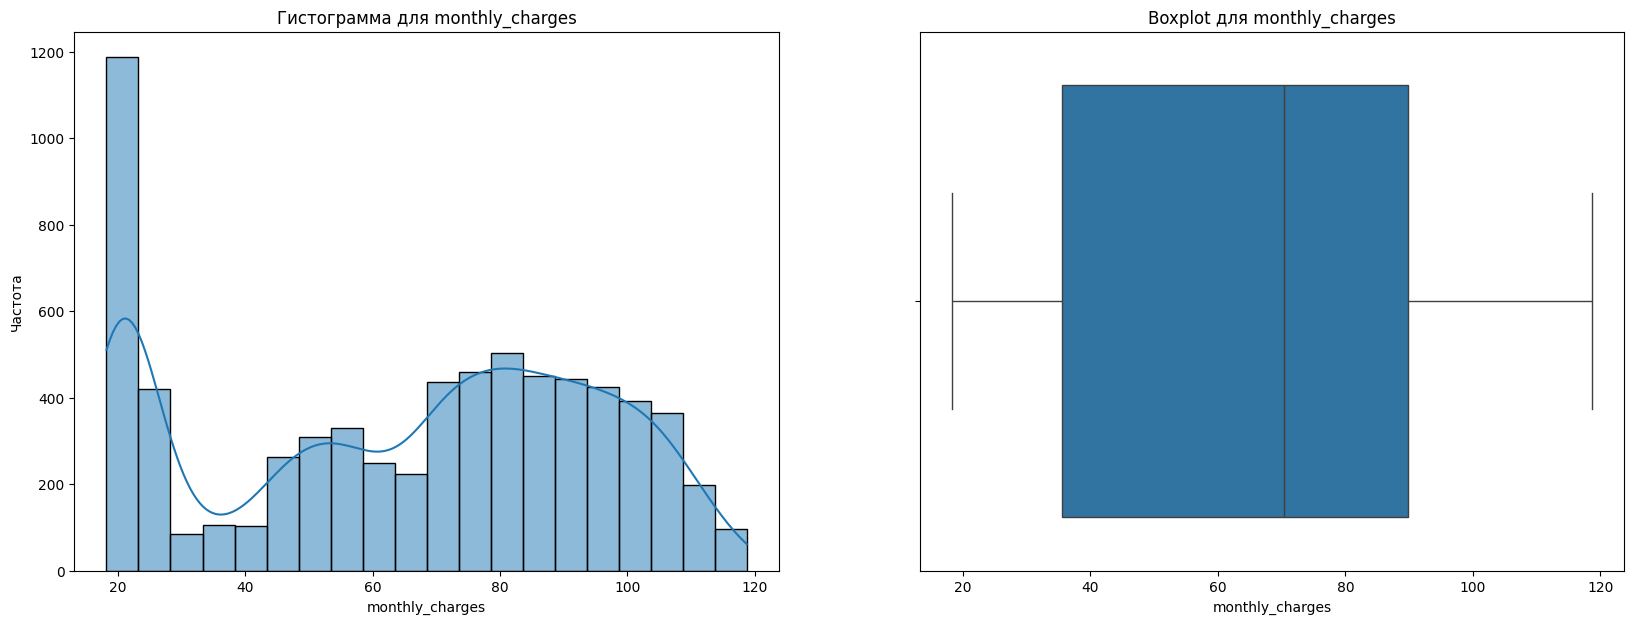

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.histplot(contract['monthly_charges'].values, kde=True, bins=20, ax=axes[0])
sns.boxplot(data=contract['monthly_charges'], orient='h', ax=axes[1])

axes[0].set_title('Гистограмма для monthly_charges')
axes[0].set_xlabel('monthly_charges')
axes[0].set_ylabel('Частота')

axes[1].set_title('Boxplot для monthly_charges')
axes[1].set_xlabel('monthly_charges')
axes[1].set_ylabel('')
plt.show()

Выводы по графику:
 * Среди клиентов преобладают контракты с минимальной ежемесячной платой около 20 долларов
 * Есть еще два пика частот: около 55 и 80 долларов.
 * Медиана около 70 долларов
 * Среднее значение около 65 долларов

#### Статистика по полю 'total_charges'

In [28]:
contract['total_charges'].describe()

count     7043
unique    6658
top           
freq        11
Name: total_charges, dtype: object

В столбце "total_charges" есть пропуски в строках, где дата заключения договора соответствует актуальной дате датасета. Т.е. клиент заключил договор, но не наступил срок первой оплаты, при этом известна ежемесячная плата по договору. Заменяем пропуски на значения из столбца "monthly_charges".

In [29]:
contract.loc[contract['total_charges'] == ' ']

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,duration,target
488,4472-LVYGI,2020-02-01,2020-02-01,Two year,Yes,Bank transfer (automatic),52.55,,0,0
753,3115-CZMZD,2020-02-01,2020-02-01,Two year,No,Mailed check,20.25,,0,0
936,5709-LVOEQ,2020-02-01,2020-02-01,Two year,No,Mailed check,80.85,,0,0
1082,4367-NUYAO,2020-02-01,2020-02-01,Two year,No,Mailed check,25.75,,0,0
1340,1371-DWPAZ,2020-02-01,2020-02-01,Two year,No,Credit card (automatic),56.05,,0,0
3331,7644-OMVMY,2020-02-01,2020-02-01,Two year,No,Mailed check,19.85,,0,0
3826,3213-VVOLG,2020-02-01,2020-02-01,Two year,No,Mailed check,25.35,,0,0
4380,2520-SGTTA,2020-02-01,2020-02-01,Two year,No,Mailed check,20.00,,0,0
5218,2923-ARZLG,2020-02-01,2020-02-01,One year,Yes,Mailed check,19.70,,0,0
6670,4075-WKNIU,2020-02-01,2020-02-01,Two year,No,Mailed check,73.35,,0,0


In [30]:
contract.dtypes

customer_id                     str
begin_date           datetime64[us]
end_date             datetime64[us]
type                            str
paperless_billing               str
payment_method                  str
monthly_charges             float64
total_charges                   str
duration                      int64
target                        int64
dtype: object

In [31]:
spaces = contract.loc[contract['total_charges'] == ' '].index.to_list()
spaces

[488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754]

In [32]:
contract.loc[spaces, 'total_charges'] = contract.loc[spaces, 'monthly_charges'].astype(str)

In [33]:
#contract.loc[contract['total_charges'] == ' ', 'total_charges'] = contract.loc[contract['total_charges'] == ' ', 'monthly_charges']

In [34]:
contract['total_charges'] = contract['total_charges'].astype(float)

In [35]:
contract.loc[spaces]

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,duration,target
488,4472-LVYGI,2020-02-01,2020-02-01,Two year,Yes,Bank transfer (automatic),52.55,52.55,0,0
753,3115-CZMZD,2020-02-01,2020-02-01,Two year,No,Mailed check,20.25,20.25,0,0
936,5709-LVOEQ,2020-02-01,2020-02-01,Two year,No,Mailed check,80.85,80.85,0,0
1082,4367-NUYAO,2020-02-01,2020-02-01,Two year,No,Mailed check,25.75,25.75,0,0
1340,1371-DWPAZ,2020-02-01,2020-02-01,Two year,No,Credit card (automatic),56.05,56.05,0,0
3331,7644-OMVMY,2020-02-01,2020-02-01,Two year,No,Mailed check,19.85,19.85,0,0
3826,3213-VVOLG,2020-02-01,2020-02-01,Two year,No,Mailed check,25.35,25.35,0,0
4380,2520-SGTTA,2020-02-01,2020-02-01,Two year,No,Mailed check,20.00,20.00,0,0
5218,2923-ARZLG,2020-02-01,2020-02-01,One year,Yes,Mailed check,19.70,19.70,0,0
6670,4075-WKNIU,2020-02-01,2020-02-01,Two year,No,Mailed check,73.35,73.35,0,0


In [36]:
contract['total_charges'].describe()

count    7043.000000
mean     2115.377573
std      2112.678861
min        19.050000
25%       436.750000
50%      1343.350000
75%      3236.690000
max      9221.380000
Name: total_charges, dtype: float64

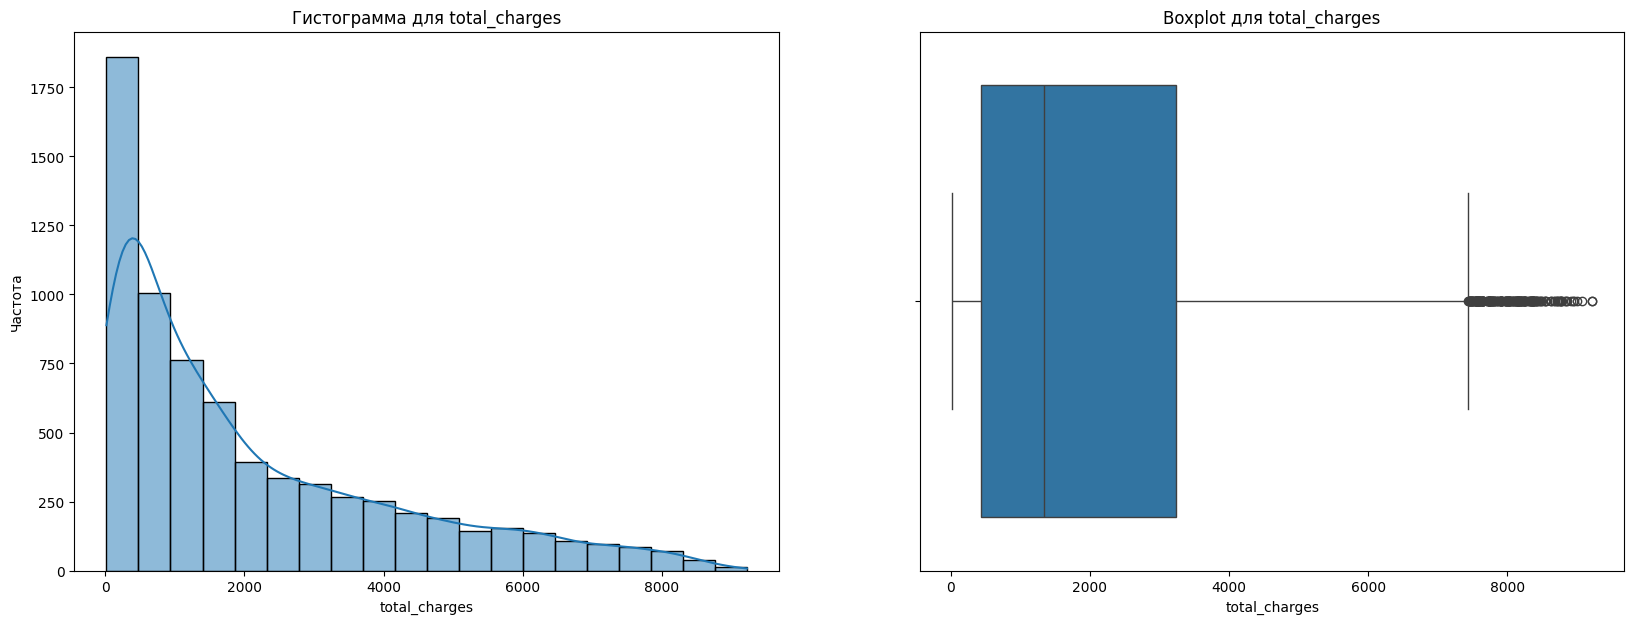

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.histplot(data=contract['total_charges'], bins=20, kde=True, ax=axes[0])
sns.boxplot(data=contract['total_charges'], orient='h', ax=axes[1])

axes[0].set_title('Гистограмма для total_charges')
axes[0].set_xlabel('total_charges')
axes[0].set_ylabel('Частота')

axes[1].set_title('Boxplot для total_charges')
axes[1].set_xlabel('total_charges')
axes[1].set_ylabel('')
plt.show()

Выводы по графику:
 * Среди клиентов компании у половины суммарные расходы не превышают 1350 долларов. Если учесть, что медиана месячных расходов около 70 долларов, то это клиенты привлеченные за последний год-два
 * Судя по гистограме, можно предположить, что не так давно прошло активное привлечение новых клиентов.
 * На графике видна проблема компании, что в течение примерно двух лет значительная часть клиентов уходит (с 1800 количество клиентов падает до примерно 500)

#### Статистика по полю 'duration'

In [38]:
contract['duration'].describe()

count    7043.000000
mean      898.555729
std       683.130510
min         0.000000
25%       276.000000
50%       761.000000
75%      1461.000000
max      2314.000000
Name: duration, dtype: float64

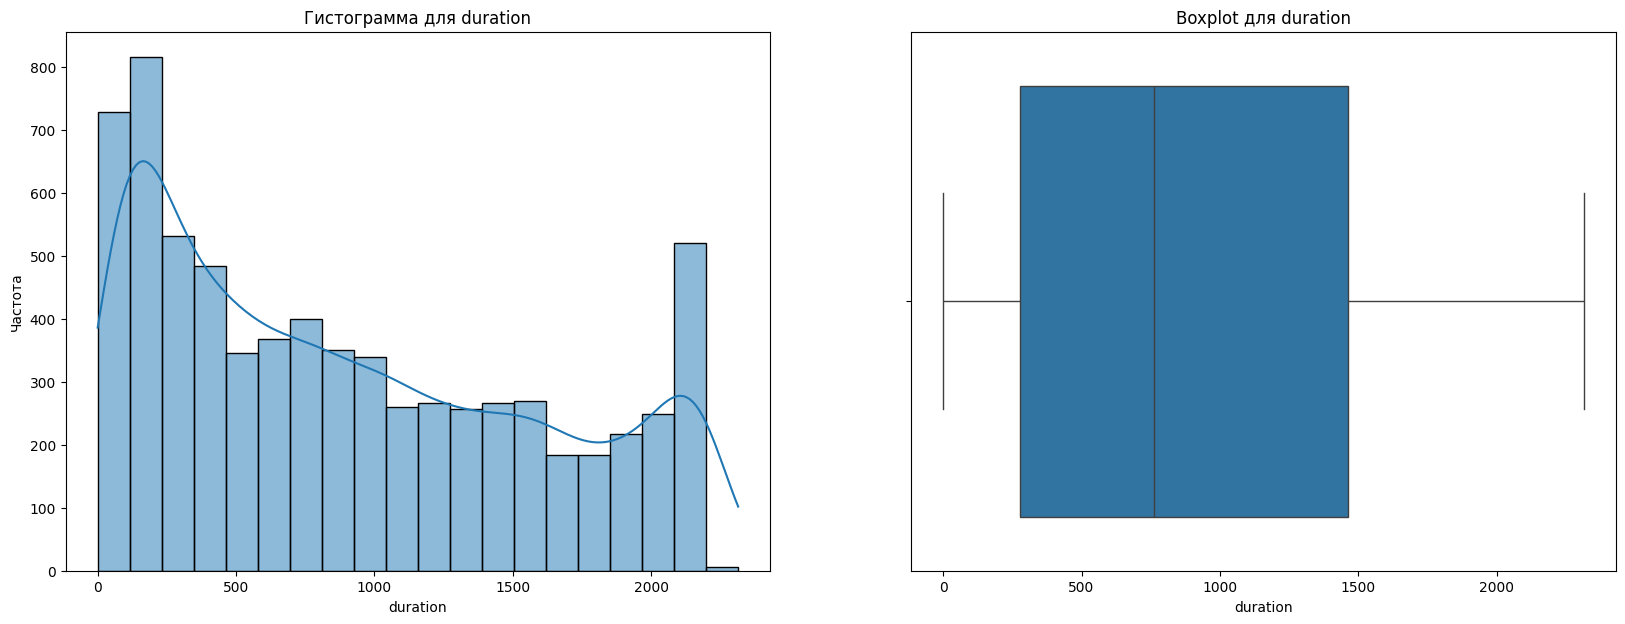

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.histplot(data=contract['duration'], bins=20, kde=True, ax=axes[0])
sns.boxplot(data=contract['duration'], orient='h', ax=axes[1])

axes[0].set_title('Гистограмма для duration')
axes[0].set_xlabel('duration')
axes[0].set_ylabel('Частота')

axes[1].set_title('Boxplot для duration')
axes[1].set_xlabel('duration')
axes[1].set_ylabel('')
plt.show()

Выводы по графику:
 * Виден сильный отток клиентов после 250 дней и после 500 дней.
 * Далее падение количества клиентов идет ступенчато: после 1000 дней и после 1600 дней. Возможно раз в 500 дней компания меняет условия предоставления услуг.
 * Видно значительное количество постоянных клиентов, которые остались с компанией 2000 дней и более.
 * Среднее значение 900 дней, медиана 760 дней - перекос из-за постоянных клиентов, которые остаются похоже с момента основания компании. Возможно у них действуют дешевые пожизненные тарифы, как у первых клиентов.

#### Изучение категориальных признаков

In [40]:
contract.head()

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,duration,target
0,7590-VHVEG,2020-01-01,2020-02-01,Month-to-month,Yes,Electronic check,29.85,31.04,31,0
1,5575-GNVDE,2017-04-01,2020-02-01,One year,No,Mailed check,56.95,2071.84,1036,0
2,3668-QPYBK,2019-10-01,2020-02-01,Month-to-month,Yes,Mailed check,53.85,226.17,123,0
3,7795-CFOCW,2016-05-01,2020-02-01,One year,No,Bank transfer (automatic),42.30,1960.60,1371,0
4,9237-HQITU,2019-09-01,2020-02-01,Month-to-month,Yes,Electronic check,70.70,353.50,153,0


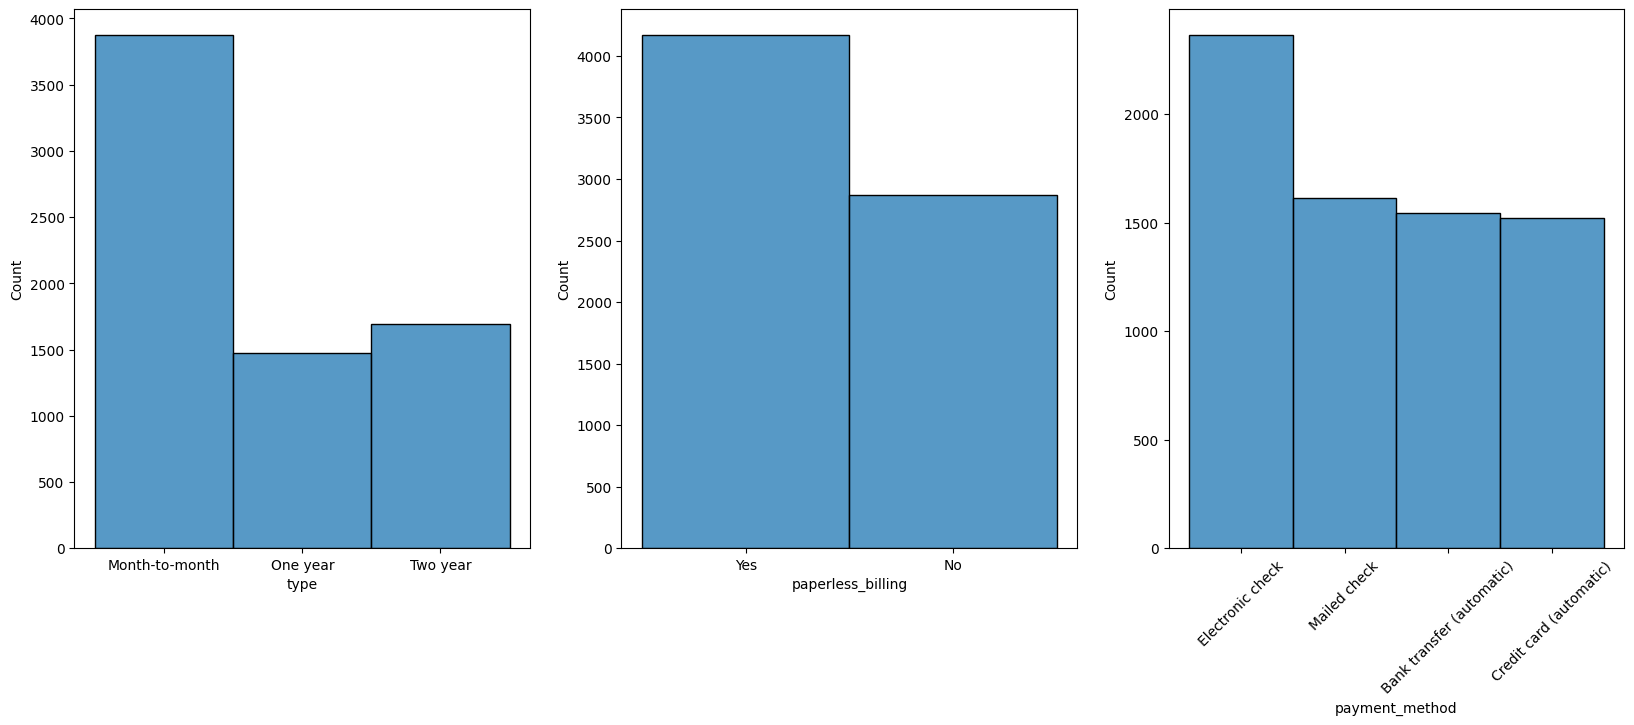

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sns.histplot(data=contract['type'], ax=axes[0])
sns.histplot(data=contract['paperless_billing'], ax=axes[1])
sns.histplot(data=contract['payment_method'], ax=axes[2])
plt.xticks(rotation=45)
plt.show()

Вывод по графикам:
 * Среди типа оплаты преобладает ежемесячная.
 * Люди предпочитают больше платить электронным способом.
 * Оплата чаще проходит с помощью электронного чека.

### Датасет "personal"

In [42]:
personal.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerID     7043 non-null   str  
 1   gender         7043 non-null   str  
 2   SeniorCitizen  7043 non-null   int64
 3   Partner        7043 non-null   str  
 4   Dependents     7043 non-null   str  
dtypes: int64(1), str(4)
memory usage: 275.2 KB


In [43]:
personal.head()

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [44]:
personal.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents'], dtype='str')

In [45]:
correct_column_names = ['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents']

In [46]:
personal.columns = correct_column_names
personal.head()

,customer_id,gender,senior_citizen,partner,dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


Во всех датасетах бинарный категориальный признак представлен ввиде двух строковых значений Yes/No. Сделаем также для единообразия с полем SeniorCitizen

In [47]:
personal['senior_citizen'] = ['No' if x == 0 else 'Yes' for x in personal['senior_citizen']]

In [48]:
personal.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customer_id     7043 non-null   str  
 1   gender          7043 non-null   str  
 2   senior_citizen  7043 non-null   str  
 3   partner         7043 non-null   str  
 4   dependents      7043 non-null   str  
dtypes: str(5)
memory usage: 275.2 KB


In [49]:
personal.duplicated().sum()

np.int64(0)

In [50]:
columns = personal.columns.to_list()
columns

['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents']

In [51]:
columns_to_check = ['gender', 'senior_citizen', 'partner', 'dependents']

In [52]:
for i in columns_to_check:
    print(f'Уникальные значения для поля {i}:\n{personal[i].unique()}')

Уникальные значения для поля gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
Уникальные значения для поля senior_citizen:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
Уникальные значения для поля partner:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
Уникальные значения для поля dependents:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


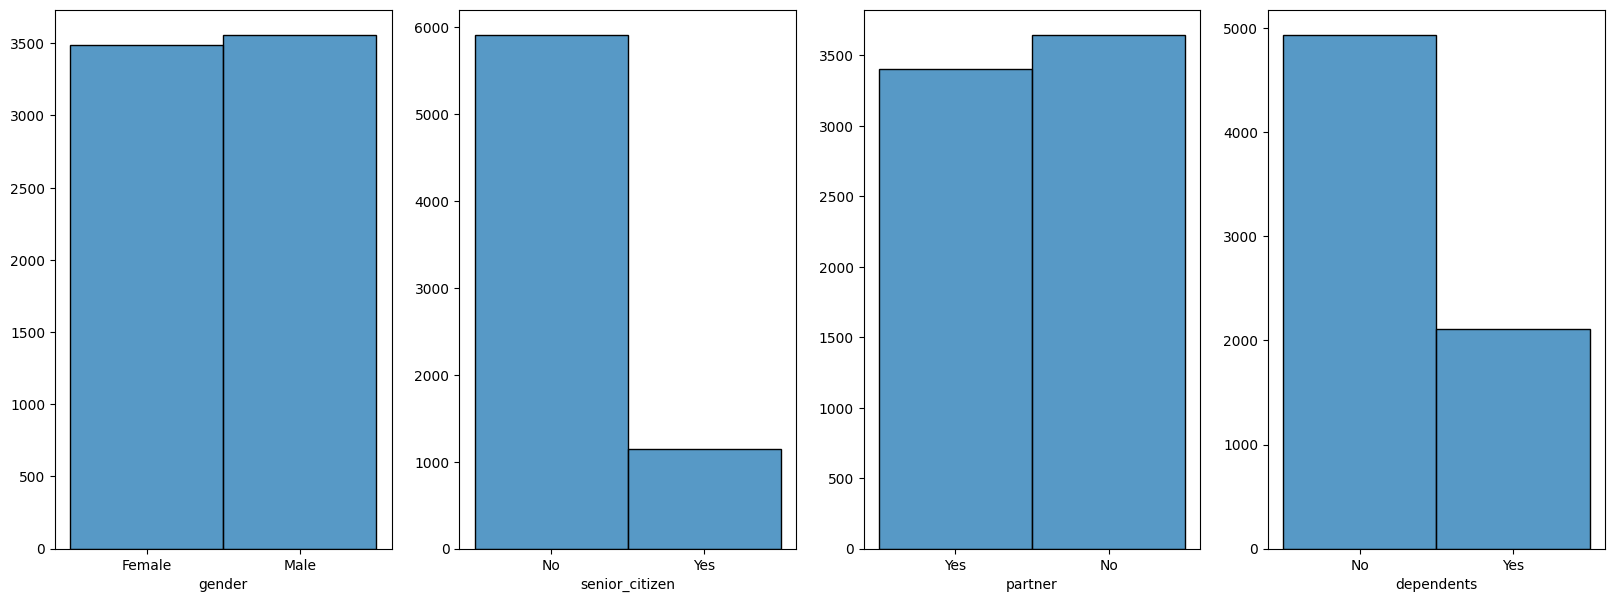

In [53]:
fig, axes = plt.subplots(1, len(columns_to_check), figsize=(20, 7))

for i, col in enumerate(columns_to_check):
    sns.histplot(data=personal[col], ax=axes[i])
    axes[i].set_ylabel('')
plt.show()

Выводы по датасету:
 * Дуликатов нет
 * Пропусков нет
 * Ошибок среди значений столбцов нет.
 * Пенсионеров среди пользователей в 6 раз меньше
 * Клиентов без детей в два с половиной раза больше

### Датасет "internet"

In [54]:
internet.info()

<class 'pandas.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customerID        5517 non-null   str  
 1   InternetService   5517 non-null   str  
 2   OnlineSecurity    5517 non-null   str  
 3   OnlineBackup      5517 non-null   str  
 4   DeviceProtection  5517 non-null   str  
 5   TechSupport       5517 non-null   str  
 6   StreamingTV       5517 non-null   str  
 7   StreamingMovies   5517 non-null   str  
dtypes: str(8)
memory usage: 344.9 KB


In [55]:
internet.head()

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [56]:
internet.columns

Index(['customerID', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'],
      dtype='str')

In [57]:
correct_column_names = ['customer_id', 'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies']

In [58]:
internet.columns = correct_column_names
internet.head()

,customer_id,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [59]:
internet.duplicated().sum()

np.int64(0)

In [60]:
columns = internet.columns.to_list()
columns

['customer_id',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies']

In [61]:
columns_to_check = ['internet_service', 
                    'online_security',
                    'online_backup',
                    'device_protection',
                    'tech_support',
                    'streaming_tv',
                    'streaming_movies']

In [62]:
for i in columns_to_check:
    print(f'Уникальные значения для поля {i}:\n{internet[i].unique()}')

Уникальные значения для поля internet_service:
<StringArray>
['DSL', 'Fiber optic']
Length: 2, dtype: str
Уникальные значения для поля online_security:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
Уникальные значения для поля online_backup:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
Уникальные значения для поля device_protection:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
Уникальные значения для поля tech_support:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
Уникальные значения для поля streaming_tv:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
Уникальные значения для поля streaming_movies:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


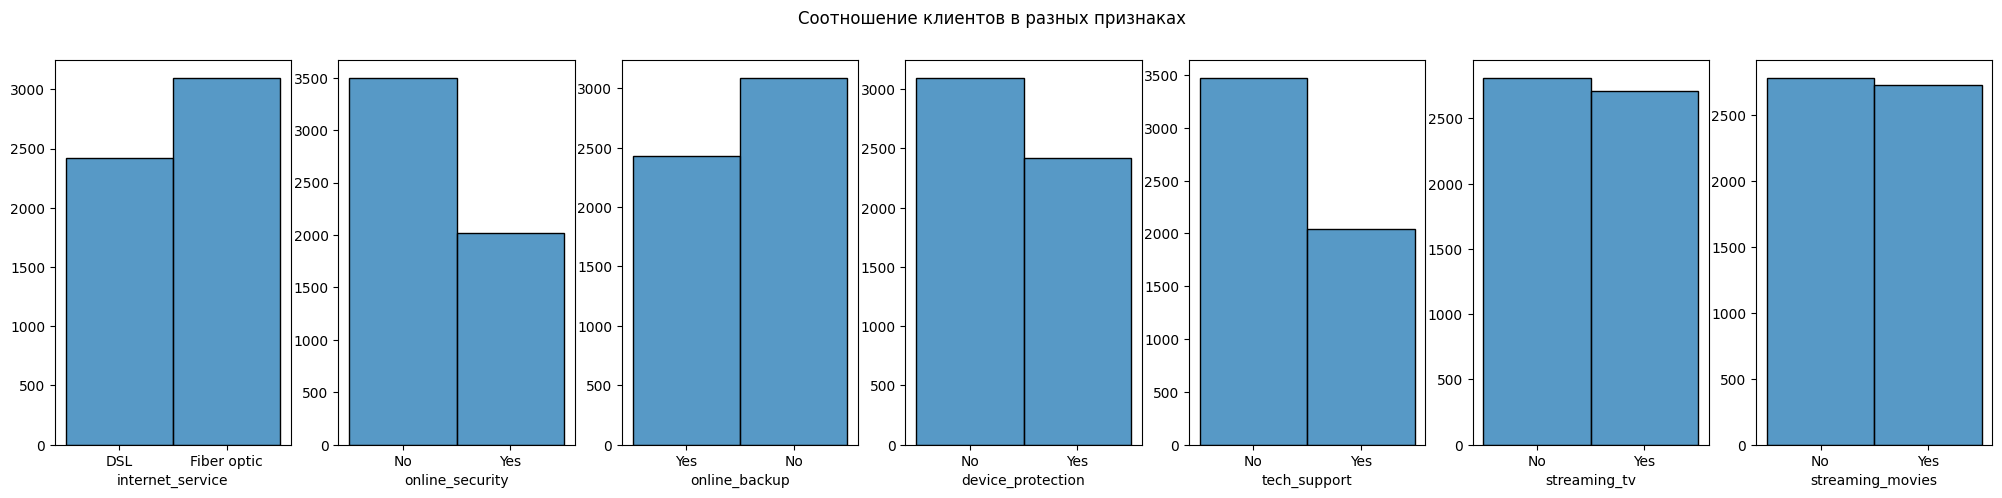

In [63]:
fig, axes = plt.subplots(1, len(columns_to_check), figsize=(25, 5))
fig.suptitle('Соотношение клиентов в разных признаках')

for i, col in enumerate(columns_to_check):
    sns.histplot(data=internet[col], ax=axes[i])
    axes[i].set_ylabel('')
plt.show()

Выводы по датасету:
 * Дуликатов нет
 * Пропусков нет
 * Ошибок среди значений столбцов нет.
 * Клиенты чаще пользуются услугой интерент безопасности и тех. поддержкой

### Датасет "phone"

In [64]:
phone.info()

<class 'pandas.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerID     6361 non-null   str  
 1   MultipleLines  6361 non-null   str  
dtypes: str(2)
memory usage: 99.5 KB


In [65]:
phone.head()

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [66]:
phone.rename(columns={'customerID': 'customer_id', 'MultipleLines': 'multiple_lines'}, inplace=True)

In [67]:
phone.duplicated().sum()

np.int64(0)

In [68]:
phone['multiple_lines'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

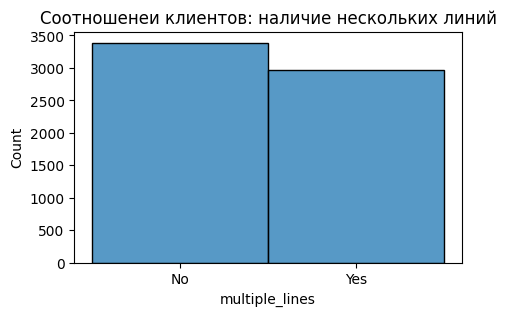

In [69]:
plt.figure(figsize=(5,3))
sns.histplot(data=phone['multiple_lines'])
plt.title('Соотношенеи клиентов: наличие нескольких линий')
plt.show()


Выводы по датасету:
 * Дуликатов нет
 * Пропусков нет
 * Ошибок среди значений столбцов нет.

### Объендинение датасетов

Перенесем поле "customer_id" во всех датасетах в индекс. Для дальнейшей работы это поле не понадобится.

In [70]:
contract.set_index('customer_id', inplace=True)
personal.set_index('customer_id', inplace=True)
internet.set_index('customer_id', inplace=True)
phone.set_index('customer_id', inplace=True)

In [71]:
phone.head()

,multiple_lines
customer_id,
5575-GNVDE,No
3668-QPYBK,No
9237-HQITU,No
9305-CDSKC,Yes
1452-KIOVK,Yes


In [72]:
dataset = contract.join([personal, internet, phone])

In [73]:
dataset.info()

<class 'pandas.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   begin_date         7043 non-null   datetime64[us]
 1   end_date           7043 non-null   datetime64[us]
 2   type               7043 non-null   str           
 3   paperless_billing  7043 non-null   str           
 4   payment_method     7043 non-null   str           
 5   monthly_charges    7043 non-null   float64       
 6   total_charges      7043 non-null   float64       
 7   duration           7043 non-null   int64         
 8   target             7043 non-null   int64         
 9   gender             7043 non-null   str           
 10  senior_citizen     7043 non-null   str           
 11  partner            7043 non-null   str           
 12  dependents         7043 non-null   str           
 13  internet_service   5517 non-null   str           
 14  online_se

In [74]:
dataset['multiple_lines'].unique()

<StringArray>
[nan, 'No', 'Yes']
Length: 3, dtype: str

При объединении датасетов есть клиенты, по которым отсутствует информация в разных признаках. Предположим, что клиент не принял решение по конкретной услуге и у нас потенциальноесть возможность ему эту услугу продать. Заполняем такие поля отдельным значением "no_info"

In [75]:
dataset.fillna('no_info', inplace=True)

,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,duration,target,gender,...,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
customer_id,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,2020-01-01,2020-02-01,Month-to-month,Yes,Electronic check,29.85,31.04,31,0,Female,...,Yes,No,DSL,No,Yes,No,No,No,No,no_info
5575-GNVDE,2017-04-01,2020-02-01,One year,No,Mailed check,56.95,2071.84,1036,0,Male,...,No,No,DSL,Yes,No,Yes,No,No,No,No
3668-QPYBK,2019-10-01,2020-02-01,Month-to-month,Yes,Mailed check,53.85,226.17,123,0,Male,...,No,No,DSL,Yes,Yes,No,No,No,No,No
7795-CFOCW,2016-05-01,2020-02-01,One year,No,Bank transfer (automatic),42.30,1960.60,1371,0,Male,...,No,No,DSL,Yes,No,Yes,Yes,No,No,no_info
9237-HQITU,2019-09-01,2020-02-01,Month-to-month,Yes,Electronic check,70.70,353.50,153,0,Female,...,No,No,Fiber optic,No,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6840-RESVB,2018-02-01,2020-02-01,One year,Yes,Mailed check,84.80,2035.20,730,0,Male,...,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Yes
2234-XADUH,2014-02-01,2020-02-01,One year,Yes,Credit card (automatic),103.20,7430.40,2191,0,Female,...,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes
4801-JZAZL,2019-03-01,2020-02-01,Month-to-month,Yes,Electronic check,29.60,325.60,337,0,Female,...,Yes,Yes,DSL,Yes,No,No,No,No,No,no_info


In [76]:
dataset.info()

<class 'pandas.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   begin_date         7043 non-null   datetime64[us]
 1   end_date           7043 non-null   datetime64[us]
 2   type               7043 non-null   str           
 3   paperless_billing  7043 non-null   str           
 4   payment_method     7043 non-null   str           
 5   monthly_charges    7043 non-null   float64       
 6   total_charges      7043 non-null   float64       
 7   duration           7043 non-null   int64         
 8   target             7043 non-null   int64         
 9   gender             7043 non-null   str           
 10  senior_citizen     7043 non-null   str           
 11  partner            7043 non-null   str           
 12  dependents         7043 non-null   str           
 13  internet_service   7043 non-null   str           
 14  online_se

### Корреляционный анализ

In [77]:
num_cols_for_phik = ['monthly_charges', 'total_charges', 'duration']


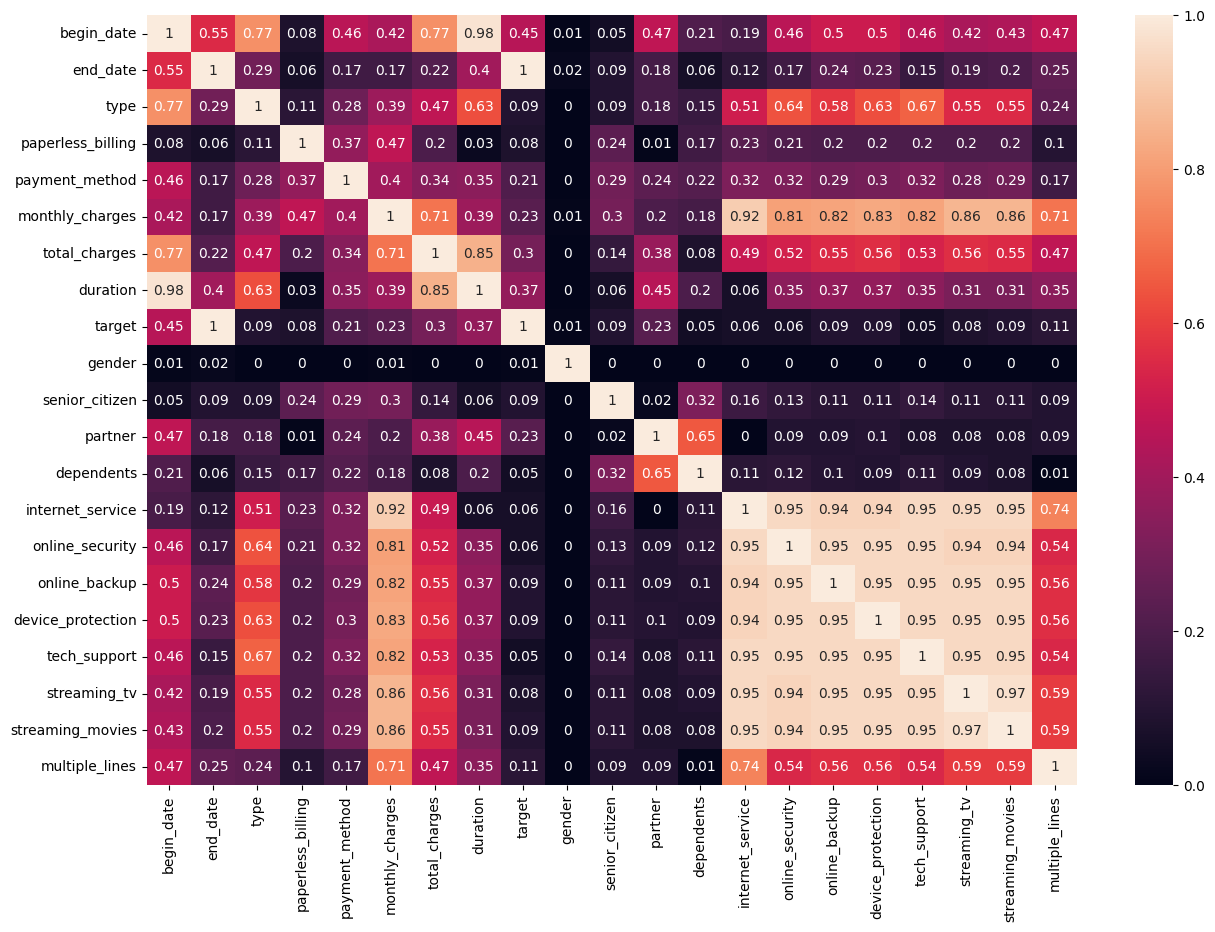

In [78]:
phik_matrix = dataset.phik_matrix(interval_cols=num_cols_for_phik)
phik_matrix = np.round(phik_matrix, 2)
fig, axes = plt.subplots(1, figsize=(15,10))
sns.heatmap(phik_matrix, annot=True, ax=axes);

Выводы по корреляционному анализу:
 * Для построения модеи исключаем поля:
     * begin_date - сильная корреляция с полем duration. Поле duration представляет большую ценность, т.к. оно числовое, а не в формате даты.
     * end_date - 100% корреляция с таргетом.
 * Поле monthly_charges сильно корелирует с интернет услугами. По сути, если есть ежемесячный платеж, то практически на 100% есть интренет и сопутствующие услуги. 
 * Интернет услуги сильно коррелируют между собой, возможно идут в виде пакетного предложения по-умолчанию при подключении интернета. Предлагаю оставить один столбец internet_service

In [79]:
dataset.drop(columns = ['begin_date', 
              'end_date',
              'online_security',
              'online_backup',
              'device_protection',
              'tech_support',
              'streaming_tv',
              'streaming_movies'],
              inplace=True)

In [80]:
dataset.info()

<class 'pandas.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   type               7043 non-null   str    
 1   paperless_billing  7043 non-null   str    
 2   payment_method     7043 non-null   str    
 3   monthly_charges    7043 non-null   float64
 4   total_charges      7043 non-null   float64
 5   duration           7043 non-null   int64  
 6   target             7043 non-null   int64  
 7   gender             7043 non-null   str    
 8   senior_citizen     7043 non-null   str    
 9   partner            7043 non-null   str    
 10  dependents         7043 non-null   str    
 11  internet_service   7043 non-null   str    
 12  multiple_lines     7043 non-null   str    
dtypes: float64(2), int64(2), str(9)
memory usage: 1.0+ MB


In [81]:
dataset.head()

,type,paperless_billing,payment_method,monthly_charges,total_charges,duration,target,gender,senior_citizen,partner,dependents,internet_service,multiple_lines
customer_id,,,,,,,,,,,,,
7590-VHVEG,Month-to-month,Yes,Electronic check,29.85,31.04,31,0,Female,No,Yes,No,DSL,no_info
5575-GNVDE,One year,No,Mailed check,56.95,2071.84,1036,0,Male,No,No,No,DSL,No
3668-QPYBK,Month-to-month,Yes,Mailed check,53.85,226.17,123,0,Male,No,No,No,DSL,No
7795-CFOCW,One year,No,Bank transfer (automatic),42.30,1960.60,1371,0,Male,No,No,No,DSL,no_info
9237-HQITU,Month-to-month,Yes,Electronic check,70.70,353.50,153,0,Female,No,No,No,Fiber optic,No


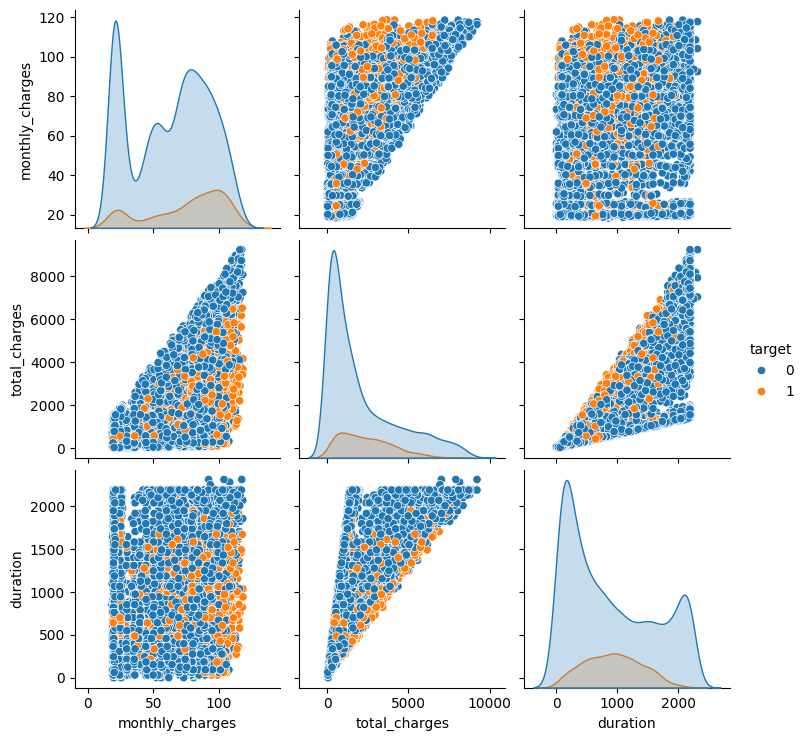

In [82]:
sns.pairplot(data=dataset, hue='target');

Комментарий к графику: 
 * скопление людей, разорвавших договор, наблюдается среди точек с наибольшим значениеми параметра monthly_charges
 * Распределение людей, разорвавших договор, по длительности оказания услуг (график duration/duration) визуально похоже на колокол со средним около 1000 дней. 
 * Максимальный темп оттока клиентов наблюдается от 0 до 500 дней, дальше график выполаживается и идет на спад.

## Подготовка данных

In [83]:
X = dataset.drop('target', axis=1)

In [84]:
y = dataset['target']

In [85]:
X.info()

<class 'pandas.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   type               7043 non-null   str    
 1   paperless_billing  7043 non-null   str    
 2   payment_method     7043 non-null   str    
 3   monthly_charges    7043 non-null   float64
 4   total_charges      7043 non-null   float64
 5   duration           7043 non-null   int64  
 6   gender             7043 non-null   str    
 7   senior_citizen     7043 non-null   str    
 8   partner            7043 non-null   str    
 9   dependents         7043 non-null   str    
 10  internet_service   7043 non-null   str    
 11  multiple_lines     7043 non-null   str    
dtypes: float64(2), int64(1), str(9)
memory usage: 973.3+ KB


In [86]:
num_cols = X.select_dtypes(include='number').columns.to_list()
num_cols

['monthly_charges', 'total_charges', 'duration']

In [87]:
cat_cols = X.select_dtypes(include='str').columns.to_list()
cat_cols

['type',
 'paperless_billing',
 'payment_method',
 'gender',
 'senior_citizen',
 'partner',
 'dependents',
 'internet_service',
 'multiple_lines']

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

In [89]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', OneHotEncoder(drop='first', sparse_output=False), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

## Обучение и выбор моделей

### Логистическая регрессия

In [90]:
pipe_lr = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('model', LogisticRegression())
    ]
)

In [91]:
param_grid = [
    {
        'model__random_state': [RANDOM_STATE],
        'model__penalty': ['l2'],
        'model__C': [0.1, 1, 10],
        'model__class_weight': ['balanced', None],
        'model__solver': ['lbfgs', 'liblinear', 'newton-cg']
    }
]

In [92]:
grid = GridSearchCV(
    pipe_lr,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    error_score='raise'
)

In [93]:
grid.fit(X_train, y_train)

C:\Users\User\Documents\Практикум_проекты_DA_почищенные\da_jupyter_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\User\Documents\Практикум_проекты_DA_почищенные\da_jupyter_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\User\Documents\Практикум_проекты_DA_почищенные\da_jupyter_venv\Lib\site-packages\sklearn\linear_model\_

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': [0.1, 1, ...], 'model__class_weight': ['balanced', None], 'model__penalty': ['l2'], 'model__random_state': [80724], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each

In [94]:
grid.best_score_

np.float64(0.7628066119089806)

In [95]:
grid.best_params_

{'model__C': 10,
 'model__class_weight': 'balanced',
 'model__penalty': 'l2',
 'model__random_state': 80724,
 'model__solver': 'lbfgs'}

In [96]:
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

### CatBoost

In [97]:
pipe_cb = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('model', CatBoostClassifier(verbose=0, random_state=RANDOM_STATE))
    ]
)

In [98]:
param_grid = {
    'model__iterations': [100, 200],  # количество итераций
    'model__depth': [4, 6, 8],  # глубина дерева
    'model__learning_rate': [0.01, 0.05, 0.1],  # скорость обучения
    'model__l2_leaf_reg': [1, 3, 5]  # коэффициент регуляризации
}


In [99]:
grid = GridSearchCV(
    pipe_cb,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    error_score='raise',
    n_jobs=-1,
    verbose=3
)

In [100]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__depth': [4, 6, ...], 'model__iterations': [100, 200], 'model__l2_leaf_reg': [1, 3, ...], 'model__learning_rate': [0.01, 0.05, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for e

In [101]:
grid.best_score_

np.float64(0.8943517150453818)

In [102]:
grid.best_params_

{'model__depth': 6,
 'model__iterations': 200,
 'model__l2_leaf_reg': 1,
 'model__learning_rate': 0.1}

In [103]:
best_model = grid.best_estimator_['model']
best_model

CatBoostClassifier(depth=6, iterations=200, l2_leaf_reg=1, learning_rate=0.1, random_state=80724, verbose=0)

In [104]:
feature_importances = best_model.get_feature_importance()
feature_importances

array([ 3.26471702,  5.9133723 ,  1.68965868,  1.34706408,  1.11615493,
        2.53642597,  1.13518978,  1.14079333,  3.33362462,  1.65663083,
        1.35633096,  0.49730531,  2.32285989,  1.86508863, 10.14353178,
       12.1986453 , 48.4826066 ])

In [105]:
pipe_cb.named_steps['preprocessor'].transformers[0][1].fit(X_train[cat_cols])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_ca

In [106]:
pipe_cb.named_steps['preprocessor'].transformers[0][1].get_feature_names_out().tolist()

['type_One year',
 'type_Two year',
 'paperless_billing_Yes',
 'payment_method_Credit card (automatic)',
 'payment_method_Electronic check',
 'payment_method_Mailed check',
 'gender_Male',
 'senior_citizen_Yes',
 'partner_Yes',
 'dependents_Yes',
 'internet_service_Fiber optic',
 'internet_service_no_info',
 'multiple_lines_Yes',
 'multiple_lines_no_info']

In [107]:
cat_cols

['type',
 'paperless_billing',
 'payment_method',
 'gender',
 'senior_citizen',
 'partner',
 'dependents',
 'internet_service',
 'multiple_lines']

In [108]:
feature_names  = pipe_cb.named_steps['preprocessor'].transformers[0][1].get_feature_names_out(input_features=cat_cols).tolist() + num_cols
feature_names

['type_One year',
 'type_Two year',
 'paperless_billing_Yes',
 'payment_method_Credit card (automatic)',
 'payment_method_Electronic check',
 'payment_method_Mailed check',
 'gender_Male',
 'senior_citizen_Yes',
 'partner_Yes',
 'dependents_Yes',
 'internet_service_Fiber optic',
 'internet_service_no_info',
 'multiple_lines_Yes',
 'multiple_lines_no_info',
 'monthly_charges',
 'total_charges',
 'duration']

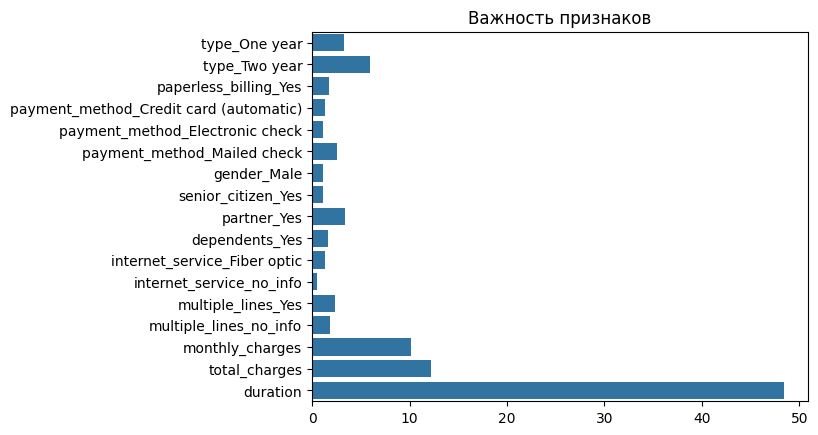

In [109]:
sns.barplot(x=feature_importances, y = feature_names)
plt.title('Важность признаков')
plt.show()

Выводы о важности признаков:
 * Модель CatBoost присвоила признаку duration наибольшее значение при определении перестанет пользоваться человек услугами компании или останется (чем дольше он пользуется услугами, тем вероятнее, что он уйдет). В этом нет ничего удивительного, рано или поздно человек задумается о смене оператора. Возможно стоит для эксперимента провести обучение заново удалив этот признак, т.к. его вес слишком большой.
 * Признак total_charges сильно корреклирует с duration, поэтому он второй по важности.
 * На третьем месте параметр monthly_charges. Его важность было видно при анализе sns.pairplot графиков. Те, кто платят много, ищут других поставщиков услуг.
 * Имеет значение срок оплаты. Люди, которые платят редко, похоже чаще покидают компанию, т.к. разовый крупный платеж возможно заставляет их искать более дешевого поставщика услуг.
 * На вероятность покинет компанию клиент или нет также влияет семейное положение. Клиенты состоящие в браке считают каждую копейку =)

## Тестирование

In [110]:
preds_test = grid.best_estimator_.predict_proba(X_test)[:, 1]
preds_test

array([0.02035049, 0.00726999, 0.05215907, ..., 0.00498578, 0.41863898,
       0.04737824], shape=(1761,))

In [111]:
roc_auc = roc_auc_score(y_test, preds_test)
roc_auc

0.9074994020349212

In [112]:
fpr, tpr, thresholds = roc_curve(y_test, preds_test)

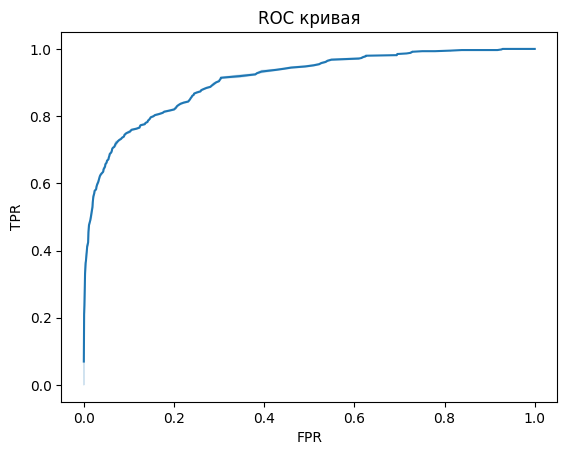

In [113]:
sns.lineplot(x=fpr, y=tpr)
plt.title('ROC кривая')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

In [114]:
preds = grid.best_estimator_.predict(X_test)
preds

array([0, 0, 0, ..., 0, 0, 0], shape=(1761,))

In [115]:
cm = confusion_matrix(y_test, preds)
cm

array([[1445,   19],
       [ 153,  144]])

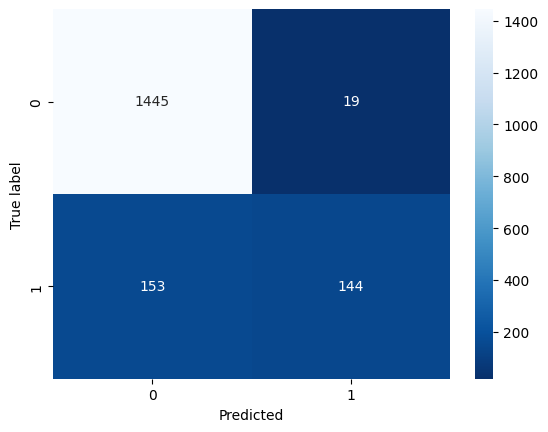

In [116]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.ylabel('True label')
plt.xlabel('Predicted'); 

## Выводы

 * Проведено предварительное изучение и обработка данных. Исключены коллинеарные признаки, ухудшающие качество работы модели. Добавлен новый признак duration, оценивающий как долго клиент пользуется услугами компании. Данные объединены в один датасет, пропускам присвоено отдельное значение.
 * Лучший результат показала модель CatBoost. На тренировочных данных целевая метрика составляет 0.894, на тестовых 0.907 
 * Модель CatBoost присвоила признаку duration наибольшее значение при определении перестанет пользоваться человек услугами компании или останется (чем дольше он пользуется услугами, тем вероятнее, что он уйдет). Рано или поздно человек задумается о смене оператора, если его не мотивировать остаться в компании.
 * Признак total_charges сильно коррелирует с duration, поэтому он второй по важности.
 * На третьем месте параметр monthly_charges. Те, кто платят много, ищут других поставщиков услуг.
 * Имеет значение срок оплаты. Люди, которые платят редко, похоже чаще покидают компанию, т.к. разовый крупный платеж, возможно, заставляет их искать более дешевого поставщика услуг.
 * На вероятность покинет компанию клиент или нет также влияет семейное положение. Клиенты состоящие в браке чаще задумываются о смене оператора, возможно в целях экономии. Промокоды им будут эффективны.
 * Рекомендации по результатам исследования:
     * Стоит обратить внимание на людей, у которых большой ежемесячный/разовый платеж. Возможно стоит проанализировать их пакет услуг, предложить промокоды или другие способы сокращения разового платежа.
     * Высокий темп оттока наблюдается в первые 500 дней пользования услугами. Стоит предусмотреть промо для новых клиентов на первый год обслуживания.
     * Рассмотреть возможность перевода людей с одно/двух годовых платежей на более частые платежи. Будет возможность чаще предлагать им промокоды.